In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# # from src.simulation_module import effective_potential
# #(720/96,540/96)
# #
# plt.figure(figsize=(360/96,270/96),dpi=200)#(540/96,540/4*3/96))
# q = 0.2
# R = 0.5
# sigma = 2*R*q
# D = 2*R+sigma

# d = np.linspace(0,10,1000)

# def red_pot_AO(d,D,R):
#     pot =- D**3 * (1 - 3*d/2/D + d**3/2/D**3)
#     if d < 2*R: return 100
#     if d > D: return 0
#     else: return pot

# pot_AO = [red_pot_AO(r,D,R) for r in d]
# label = f"reduced AO potential, \nq={q}"
# plt.plot(d,pot_AO,label=label)
# plt.legend()

# DX = (D-2*R)/10
# DY = (0-min(pot_AO))/10
# plt.xlim(2*R-DX,D+2*DX)
# plt.ylim(min(pot_AO)-DY,DY)
# plt.grid()

# plt.xlabel("d/2R")
# plt.ylabel(r"$\tilde{U}_\text{AO}^*$")
# plt.tight_layout()

# plt.savefig("analysis/AO_pot.png")

In [4]:
from src.simulation_module import simulation, plot_val_over_NMC, pack_frac


###############
r_coll = 1.2
r_coll = 1.8
n_part = 600
# n_part = 2000

steps = 1e4
steps = 1e5



##########################
q = 0.2                 ##
r_part = r_coll*q       ##
box = 7                 ##
V = box**3              ##
n_coll = 2              ##
##########################



packing_fract_coll = pack_frac(r_coll,n_coll,V)
packing_fract_part = pack_frac(r_part,n_part,V)
rho_num = (n_coll+n_part)/V
print(f"Packing fraction colloids:  {packing_fract_coll:.2}")
print(f"Packing fraction particles: {packing_fract_part:.2}")
print(f"Density of number:          {rho_num:.3}")


Packing fraction colloids:  0.14
Packing fraction particles: 0.34
Density of number:          1.76


In [5]:
# import pantarei as rei
# job = rei.Task(simulation,clear_first=False)
# seed = 0
# data = job(steps=steps,r_coll=r_coll,r_part=r_part,n_coll=n_coll,n_part=n_part,box=box,seed=seed)

In [6]:
from src.traj_memmap import Trajectory_Memmap

# trajectory_dir = data['trajectory_dir']
# trajectory_dir='.trajectories/c307f5b2e583a48a83e1e59067b1fb4e'
# trajectory_dir='.trajectories/4884c0d38068fea162b33f71efc47a52'
trajectory_dir='.trajectories/21cdcc59f6c8a14a8adbd848544c7aba'

# trajectory_dir_memmap = './save_memmap/'+f'{trajectory_dir}'
trajectory_dir_memmap = trajectory_dir
# frames = int(steps/100)
# shape = (frames,3,n_coll+n_part)

trajectory = []
with Trajectory_Memmap(trajectory_dir=trajectory_dir_memmap,mode='r') as traj:
    print(traj.shape)
    for pos in traj:
        trajectory.append(pos)

# Cumulate the distances between colloids to plot the histogram
dist_colloids = []
# for pos in trajectory:
for i in range(0,len(trajectory),1):
    pos = trajectory[i]
    rij = pos[:,1] - pos[:,0]
    rij -= box * np.round(rij / box) # minimal image convention
    dist = np.linalg.norm(rij)
    dist_colloids.append(dist/2/r_coll) # normalize by 2*r_coll


(1000, 3, 602)


In [7]:
# # figsize = (360/96,270/96)
# # plot_val_over_NMC(val=dist_colloids[:800],x_multipl=100,ylabel=f"$r/2R$",figsize=figsize,figname='analysis/steps_evol.png')
# plot_val_over_NMC(val=dist_colloids[:800],x_multipl=100,ylabel=f"$r/2R$")

In [8]:
# from src.simulation_module import visualize_3dmol

# trajectory = trajectory[:800]
# frame = trajectory[-1].T
# frame = np.array(frame, dtype=float).tolist()

# radii = [r_coll]*n_coll + [r_part]*n_part
# colors = ['white']*n_coll + ['blue']*n_part
# visualize_3dmol(frame,np.ones(3)*box,radii=radii,colors=colors)

# VIDEO

Run the following cells and then on a terminal:
```
ffmpeg -framerate 24 -i frames/frame_%04d.png -c:v libx264 -pix_fmt yuv420p video_name.mp4
```

In [9]:
from vedo import Plotter, Sphere, Box, settings
import time
import shutil
from pathlib import Path
import pantarei as rei
scheduler = rei.scheduler.ThreadScheduler(backend='process')


positions = np.array(trajectory[:800])
positions = np.array([positions[i] for i in range(0,800,8)])

radii = [r_coll]*n_coll + [r_part]*n_part
colors = ["#004aad"]*n_coll + ["#ad004A"]*n_part
# "#004aad" if r == r_coll else "#ad004A"     # "#ad6300"

(100, 3, 602)



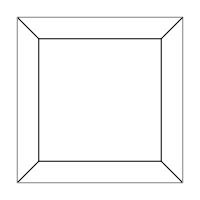

In [10]:

# Settings
# N = n_coll+n_part  # number of particles
# T = 100  # number of timesteps
T, dim, N = positions.shape
print(positions.shape)


# Initialize plotter
# settings.use_depth_peeling = True  # for better transparency, optional
settings.multi_samples = 8
# plotter = Plotter(size=(800, 600), offscreen=True, bg='lightgray')
plotter = Plotter(
    # size=(1200, 900),
    # size=(800, 600)
    # size=(360,270),
    # size=(720,540),
    size=(1280,720),
    offscreen=True,
    bg='white',
    # bg=(0.9, 0.9, 0.9),         # use RGB tuple instead of color string
    # bg2=(1, 1, 1),              # add gradient helps depth peeling
    axes=0                      # turn off axes if not needed
)
# plotter.renderer.SetUseDepthPeeling(True)
plotter.renderer.SetMaximumNumberOfPeels(100)
plotter.renderer.SetOcclusionRatio(0.1)


# Define box size and position
domain_box = Box(pos=(0, 0, 0), length=box, width=box, height=box, alpha=1.0, c='gray')
domain_box.wireframe(True)
domain_box.linewidth(1)


# # plotter.camera.SetPosition((-22.062555723336704, 0.0, 7.864801565665062))
# plotter.camera.SetPosition((14.157611626267151, -0.08148229122161865, -19.51353219271972))
# plotter.camera.SetFocalPoint((0.0, 0.0, 0.0))
# plotter.camera.SetViewUp((0.0, 1.0, 0.0))

In [11]:
# Clear the folder (or create it) before saving the new ones
frames_dir = Path('analysis/videos/frames/prova_3')
if frames_dir.exists(): shutil.rmtree(frames_dir)
frames_dir.mkdir(parents=True, exist_ok=True)

t0 = time.time()
# Animation loop
for t in range(T):
    if t % int(T/20) == 0: print(f'frame {t:3d}/{T} - {(time.time()-t0)/60:.1f}\'')
    plotter.clear()         # Clear previous frame
    plotter += domain_box   # Plot the box

    # Add particles
    # for i in range(3):
    for i in range(N):
        r = radii[i]
        color = colors[i]
        pos = positions[t,:,i]
        alpha = 1.0 if r == r_coll else 0.1

        sphere = Sphere(pos=pos, r=r, c=color, alpha=alpha)
        plotter += sphere

    # Rotate camera slowly
    azimuth = t * 360 / T  # full rotation over all frames
    plotter.camera.Azimuth(azimuth / T)  # small change per frame
    # if t >= T*0.8:
    #     print(plotter.camera.GetPosition())
    #     print(plotter.camera.GetFocalPoint())
    #     print(plotter.camera.GetViewUp())

    # Save frame
    # plotter.show(resetcam=t==0, interactive=False)
    # zoom = 1+0.01*np.exp(-t**2/(T*0.5)**2)
    zoom = 1
    plotter.show(resetcam=t==0, interactive=False,zoom=zoom)
    plotter.screenshot(f"{frames_dir}/frame_{t:04d}.png")
plotter.close()

del plotter

print(f"tot time: {(time.time()-t0)/60}' - {(time.time()-t0)/T/N}")

frame   0/100 - 0.0'
frame   5/100 - 0.5'
frame  10/100 - 0.9'
frame  15/100 - 1.3'
frame  20/100 - 1.6'
frame  25/100 - 2.0'
frame  30/100 - 2.4'
frame  35/100 - 2.7'
frame  40/100 - 3.1'
frame  45/100 - 3.5'
frame  50/100 - 3.9'
frame  55/100 - 4.3'
frame  60/100 - 4.7'
frame  65/100 - 5.0'
frame  70/100 - 5.4'
frame  75/100 - 5.8'
frame  80/100 - 6.2'
frame  85/100 - 6.5'
frame  90/100 - 6.9'
frame  95/100 - 7.3'
tot time: 7.635403009255727' - 0.007610036435713404


```ffmpeg -framerate 8 -i analysis/videos/frames/prova_0/frame_%04d.png -c:v libx264 -pix_fmt yuv420p analysis/videos/system.mp4```

In [12]:
# def f(t):
#     return 1+0.01*np.exp(-t**2/(T*0.4)**2)

# t = np.linspace(0,T)

# plt.plot(t,f(t))
# plt.grid()
# plt.show()